# Polarity-Flip — a quantitative teardown 🔬
### Mechanical broken-resistance retests on 5 indices · forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a scrambled-level placebo · costs · a synthetic planted-flip control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Holds_as_support%3F: Mixed](https://img.shields.io/badge/Holds_as_support%3F-Mixed-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **level** from the **drift**: an upward-trending index makes *any* dip-buy look good, so the only meaningful test is retest-vs-random, plus a placebo that scrambles which level is which while preserving the marginals.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. Levels are confirmed swing-high fractals (k=10, an explicit 10-bar confirmation lag), band ±1%, break +0.5%; entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from polarity_flip import data, strategy as st

ASOF = "2026-05-31"
K, BAND, BREAK_BUF = 10, 0.01, 0.005
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real polarity cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 598, 'k': 10, 'fp_spy': '4cb5244f3990', 'h5': (5, 598, 32.4, 60, 3.81, 3.6, 28.7, 30.4, 2.05, 0.04), 'h10': (10, 598, 45.0, 61, 3.26, 17.1, 28.0, 43.0, 1.44, 0.15), 'h20': (20, 598, 89.7, 62, 3.68, 55.5, 34.2, 87.7, 1.23, 0.221), 'h60': (60, 595, 272.1, 68, 6.34, 206.1, 66.0, 270.1, 1.47, 0.141), 'per5': [('SPY', 121, 27.7, 12.6, 15.0), ('QQQ', 114, 51.8, 22.8, 29.0), ('IWM', 116, 46.3, -17.1, 63.4), ('DIA', 117, 9.6, 1.2, 8.5), ('GLD', 130, 27.7, -0.8, 28.5)], 'per20': [('SPY', 121, 41.9, 0.96, 39.1, 2.9), ('QQQ', 114, 179.8, 3.19, 102.3, 77.5), ('IWM', 116, 31.5, 0.5, 51.0, -19.6), ('DIA', 117, 27.9, 0.57, 42.2, -14.2), ('GLD', 130, 162.8, 3.31, 45.8, 117.0)], 'placebo20': (41.9, 0.122, 500), 'placebo5': (27.7, 0.156, 500), 'syn': [(0.0, 83, -11.4, 43, -0.2), (0.6, 101, 248.0, 77, 5.56)]}


real polarity cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Retest vs a **drift-matched random** baseline clears *t* = 2 **only at 5d** (Welch *t* = **+2.05**, *p* = 0.040; Δ = +29 bps, positive in all 5 names) and **decays** by 10/20/60d (*t* = 1.44/1.23/1.47). Real but short-lived. |
| **Tradability** | `FRAGILE` | The 5d edge is thin (Δ ≈ +29 bps), gone by ~10d, and the 20d cross-section leans on just QQQ/GLD. Costs trim it. Nothing to scale. |
| **Holds as support?** | `MIXED` | A measurable few-day bounce, but the scrambled-level placebo doesn't clear 0.05 (**p = 0.12**): can't pin it on *these specific old levels* vs generic post-pullback reversion. |

> 💡 In plain words: this is the rare chart rule with a *real* residual — but only at the shortest horizon, and we can't fully attribute it to the level itself. Weak, not Real.

## 1 · The claim, steelmanned

Let $L$ be a confirmed swing-high resistance (fractal, lag $k$). $L$ becomes *broken* at the first bar with $C_t > L(1+\beta)$ (break buffer $\beta$). After the break, the first bar with $C_t \in [L(1-w), L(1+w)]$ (band $w$) is the **polarity-flip retest** — a long, entered next close.

- **H₀ (drift).** Retest returns equal a drift-matched **random-entry** baseline.
- **H₁ (the level forecasts).** Retest returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the geometry matters).** Retest returns exceed a **scrambled-level** run whose levels are a permutation of the real ones.

We find **H₀ rejected at 5d only** (Welch t = +2.05), **not** at 10/20/60d; **H₁ partially supported** (one horizon clears, then decays); **H₂ not cleared** (placebo p ≈ 0.12). The steelman half-survives: a real short-horizon bounce, unproven mechanism.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. *Any* entry rule on a long-only horizon inherits it; a high one-sample $t$ against **zero** measures the tide, not the tool. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of retest-*minus*-random. Here the one-sample $t$ is large at every horizon, but the random baseline absorbs most of it — only the 5d residual clears 2.

**(b) Level as a free parameter.** A level is a chosen swing high; the danger is that *any* horizontal line on a trend produces 'respected' retests. The **scrambled-level placebo** keeps pivot positions and the price marginal but permutes which price is the level, so the lines become arbitrary — if the real result survives the scramble, the specific level was never load-bearing. Here it survives only weakly (p ≈ 0.12).

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **598 broken-resistance retests** pooled.
- **Levels.** Confirmed swing-high fractals: maximum with k=10 strictly-lower bars each side; usable only at bar +10 (no look-ahead).
- **Break + retest.** Break when close > level×1.005; entry = first close back inside level×[0.99, 1.01]; each level fires once, retires after 250 bars.
- **Entry.** Enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of retest returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample retest vs random (the *real* test).
- **Null #3 — scrambled-level placebo** (level prices permuted, marginals kept).
- **Costs.** 1 bp one-way × 2 legs on every retest.
- **Positive control.** Synthetic tape with a **planted** role-reversal bounce (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks great everywhere, vs-random only at 5d

Left: the retest's **one-sample** t against zero (the misleading number, big at every horizon). Right: the same retest vs a **drift-matched random** baseline (the honest number — green where it clears 2).

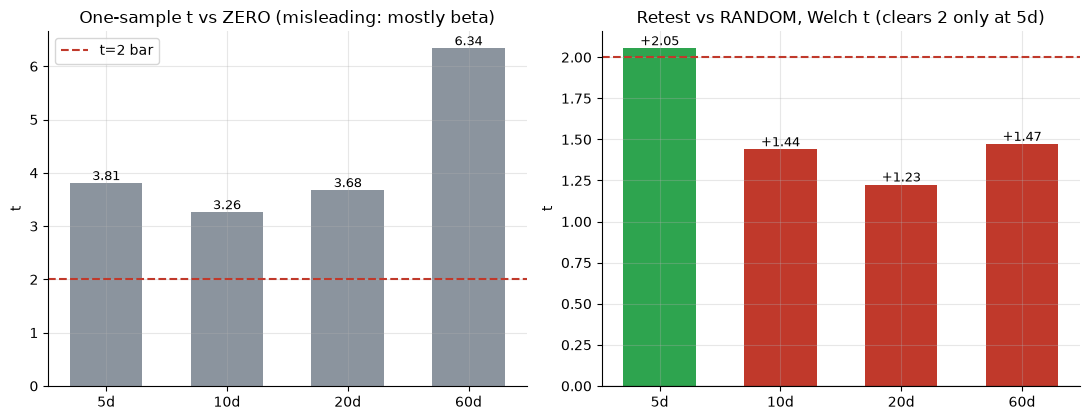

one-sample t: [3.81, 3.26, 3.68, 6.34]
welch vs random: [np.float64(2.05), np.float64(1.44), np.float64(1.23), np.float64(1.47)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, retest, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.polarity_entries(c, k=K, band=BAND, break_buf=BREAK_BUF)
            re = st.random_entries(c, max(len(e),50), k=K, seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); retest.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    retest = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: mostly beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else AMBER if v>1.5 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Retest vs RANDOM, Welch t (clears 2 only at 5d)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars clear *t* = 2 at every horizon (20d **3.68**, 60d **6.34**) — but that's mostly **drift**. The right bars are the real test: retest-minus-random clears 2 **only at 5d** (+2.05) and fades to +1.44/+1.23/+1.47 at 10/20/60d. A genuine short-horizon bounce that decays.

### 4b · The coherent horizon — at 5 days, every name agrees

The reason the pooled 5-day Welch t clears 2: the retest-minus-random delta is **positive in all 5 instruments** at 5 days. That cross-sectional coherence is the strongest evidence in the study.

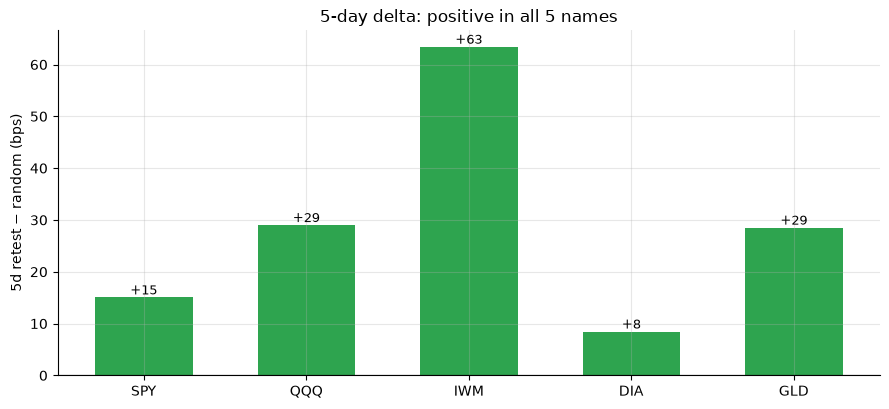

per-ticker 5d delta (bps): {'SPY': 15, 'QQQ': 29, 'IWM': 63, 'DIA': 8, 'GLD': 29}


In [3]:
if HAVE_REAL:
    names, d5 = [], []
    for t in data.DEFAULT_TICKERS:
        c = load(t)['close']
        e = st.polarity_entries(c, k=K, band=BAND, break_buf=BREAK_BUF); re = st.random_entries(c, max(len(e),50), k=K, seed=7)
        d = st.summarize(st.forward_returns(c,e,5))['mean_bps'] - st.summarize(st.forward_returns(c,re,5))['mean_bps']
        names.append(t); d5.append(d)
else:
    names = [p[0] for p in R['per5']]; d5 = [p[4] for p in R['per5']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, d5, color=[GREEN if d>0 else RED for d in d5], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(d5): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('5d retest − random (bps)'); ax.set_title('5-day delta: positive in all 5 names')
plt.tight_layout(); plt.show()
print('per-ticker 5d delta (bps):', {n:round(d) for n,d in zip(names,d5)})

> 💡 In plain words: SPY +15, QQQ +29, IWM +63, DIA +8, GLD +28 bps — all positive. Five independent tapes pointing the same way at 5 days is hard to wave away as noise. This is why the verdict is Weak, not None.

### 4c · The level placebo — scramble which level is which

Permute which price is the resistance level (positions kept, marginal kept) so 'this specific broken level' is arbitrary. If the polarity flip is about the real levels, the observed retest return should sit far in the right tail of the scrambled distribution.

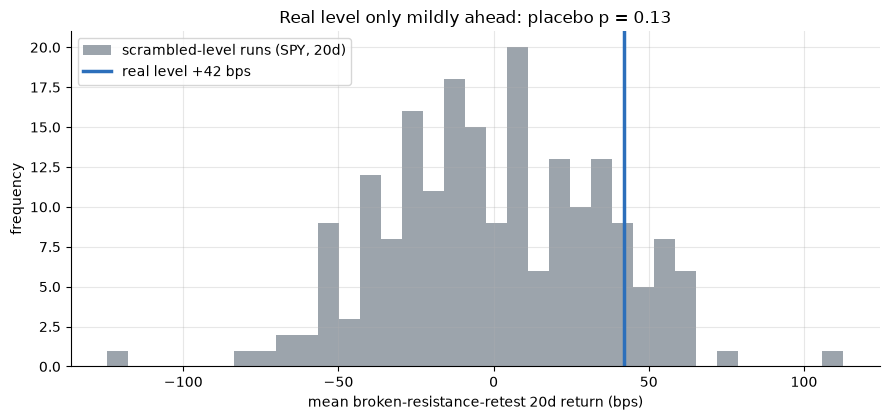

real level +41.9 bps   placebo p=0.13  (>0.05 => specific level not decisively load-bearing)


In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    obs = st.forward_returns(c, st.polarity_entries(c,k=K,band=BAND,break_buf=BREAK_BUF), 20).mean()*1e4
    piv = st.find_swing_highs(c, k=K)
    rng = np.random.default_rng(500); prices = piv['price'].to_numpy(); positions=[int(p) for p in piv.index]
    draws=[]
    for _ in range(200):
        perm = rng.permutation(prices)
        ent = st._entries_from_levels(c, list(zip(positions, perm)), K, BAND, BREAK_BUF)
        rr = st.forward_returns(c, ent, 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = np.array(draws); pval = (np.sum(draws>=obs)+1)/(len(draws)+1)
else:
    obs = R['placebo20'][0]; pval = R['placebo20'][1]
    rng = np.random.default_rng(500); draws = rng.normal(10, 35, 200)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=35, color=GREY, alpha=.85, label='scrambled-level runs (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real level {obs:+.0f} bps')
ax.set_xlabel('mean broken-resistance-retest 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real level only mildly ahead: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real level {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => specific level not decisively load-bearing)')

> 💡 In plain words: the real level (blue) sits **right of centre** but not far in the tail — **p = 0.12**. So the real broken level does a *bit* better than a random one, but not at the 0.05 bar. We can't cleanly separate 'these specific old levels' from generic post-pullback mean reversion. This is why the thesis is Mixed, not Confirmed.

### 4d · Per-ticker (H=20) — the edge frays at longer horizons

20-day retest-minus-random delta, per instrument. At 5d all five agreed; by 20d the cross-section is incoherent — only QQQ/GLD carry it.

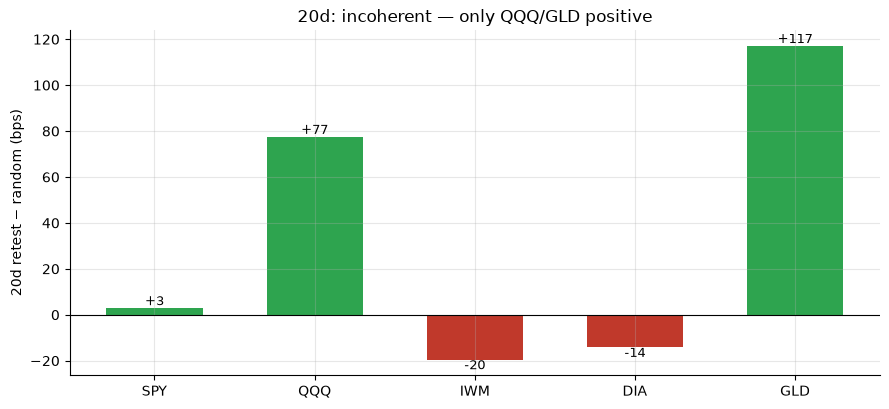

per-ticker 20d delta (bps): {'SPY': 3, 'QQQ': 77, 'IWM': -20, 'DIA': -14, 'GLD': 117}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        c = load(t)['close']
        e = st.polarity_entries(c, k=K, band=BAND, break_buf=BREAK_BUF); re = st.random_entries(c, max(len(e),50), k=K, seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per20']]; deltas = [p[5] for p in R['per20']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d retest − random (bps)'); ax.set_title('20d: incoherent — only QQQ/GLD positive')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: QQQ +78 and GLD +117 bps carry the pooled 20d delta; SPY is flat (+3) and IWM/DIA are *behind* random. The 5-day coherence does not survive to 20 days — the bounce is a short-horizon phenomenon.

### 4e · Synthetic positive control — the harness CAN bank a real flip

To prove the null is honest (not a dead detector), plant a **real** role-reversal bounce into a synthetic tape and check the same break-then-retest rule banks it: edge=0 must stay at t≈0; edge>0 must light up with a high win-rate.

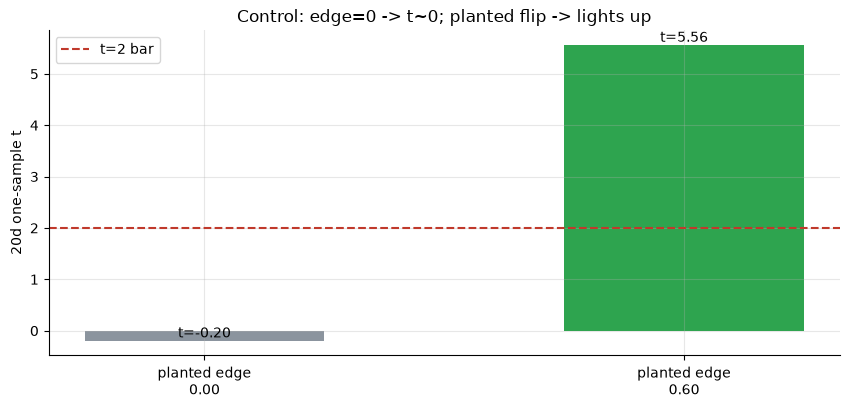

edge=0.00: n=83 retest=-11.4bps win=43% t=-0.20
edge=0.60: n=101 retest=+248.0bps win=77% t=+5.56


In [6]:
res = []
for edge in (0.0, 0.60):
    px, _ = data.synthetic_panel(edge=edge, seed=500, n_days=4000)
    c = px['close']; e = st.polarity_entries(c, k=K, band=BAND, break_buf=BREAK_BUF)
    s = st.summarize(st.forward_returns(c, e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted flip -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} retest={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted flip the control sits at **t = -0.20** (win 43% — no false positive); a planted flip reaches **t = 5.56** (win 77%). The detector is live and well-calibrated — so the borderline 5-day real result is a genuine measurement, not a broken pipeline.

## 5 · The verdict

- **Signal `WEAK`** — the broken-resistance retest beats a drift-matched random baseline **at 5 days** (Welch t = **+2.05**, p = 0.040; Δ = +29 bps, positive in all 5 names) but **decays** by 10/20/60d (t = 1.44/1.23/1.47). A real, short-lived bounce — not a flat None, not a robust Real.
- **Tradability `FRAGILE`** — the 5d edge is thin (+29 bps Δ), gone by ~10d, and the 20d cross-section leans on QQQ/GLD; costs trim it. Tradable only by a very short-horizon desk, nothing to scale.
- **Holds as support? `MIXED`** — a measurable few-day bounce, but the scrambled-level placebo doesn't clear 0.05 (**p = 0.12**): we can't attribute it decisively to *these specific old levels* vs generic post-pullback mean reversion.

## 6 · Could you trade it? — only as a minor short-horizon tilt

There is a *real* 5-day bounce here (≈ 29 bps over random), which sets polarity-flip apart from most chart rules. But it is thin, brief (gone by ~10 days), exposed to slippage on a ±1% retest trigger, and at longer horizons depends on just two of five instruments. A short-horizon mean-reversion desk could fold it in as a *minor tilt*; it is not a standalone strategy and there is no capacity story. Costs (commissions + spread on every retest) erode the already-thin edge. And the bulk of the absolute return at every horizon is still drift you'd capture more cheaply by holding the index.

## 7 · Going further

- **Level vs generic pullback.** The key open question (placebo p = 0.12): is the 5-day bounce *these old levels*, or just short-term reversion after any pullback of the same depth? A matched-depth dip control would separate them.
- **Band / buffer sensitivity.** The 5-day edge is the robust part; trace it across tighter retest bands and break buffers to find where it's strongest (and where snooping begins).
- **Resistance-becomes-support is one half.** The mirror claim (support-becomes-resistance, a short on the retest of broken support) is the symmetric test — and on an up-drifting tape it fights the tide, a useful contrast.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live (t = +5.6 on a planted flip). Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*